<a href="https://colab.research.google.com/github/aiyman14/DACSS-758/blob/main/Week9LabPython.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [8]:
!pip install gensim

In [9]:
# for preprocessing
from gensim.parsing.preprocessing import preprocess_string, strip_tags, strip_punctuation, strip_short
from gensim.parsing.preprocessing import strip_multiple_whitespaces, strip_numeric, remove_stopwords
# for modeling
from gensim import models
from gensim.corpora.dictionary import Dictionary
import gensim
from gensim.models.ldamodel import LdaModel, CoherenceModel
from sklearn.cluster import KMeans
# additional stuff
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
# read in data
MP_text = pd.read_csv("/content/MP_text.csv")
MP_text.head()



,Unnamed: 0,manifesto_id,manifesto_id_sen,original,cmp_code,language,party,date,title,year
0,0,61320_202011,61320_202011_90,DEMOCRATIC NATIONAL CONVENTION LAND ACKNOWLEDG...,H,english,61320,202011,2020 Democratic Party platform,2020
1,1,61320_202011,61320_202011_91,The Democratic National Committee wishes to ac...,607.3,english,61320,202011,2020 Democratic Party platform,2020
2,2,61320_202011,61320_202011_92,We honor the communities native to this contin...,607.3,english,61320,202011,2020 Democratic Party platform,2020
3,3,61320_202011,61320_202011_93,We pay our respects to the millions of Indigen...,607.3,english,61320,202011,2020 Democratic Party platform,2020
4,4,61320_202011,61320_202011_94,We respectfully acknowledge that we present th...,607.3,english,61320,202011,2020 Democratic Party platform,2020


In [11]:
# preprocess
CUSTOM_FILTERS = [lambda x: x.lower(),
                  strip_punctuation,
                  strip_multiple_whitespaces,
                  remove_stopwords]
MP_toks = [preprocess_string(item, CUSTOM_FILTERS) for item in MP_text['original']]
print(MP_toks[0:2])

[['democratic', 'national', 'convention', 'land', 'acknowledgement'], ['democratic', 'national', 'committee', 'wishes', 'acknowledge', 'gather', 'state', 'values', 'lands', 'stewarded', 'centuries', 'ancestors', 'descendants', 'tribal', 'nations', 'time', 'immemorial']]


In [12]:
# build a gensim vocabulary use the pre-processed results
dictionary_MP = Dictionary(MP_toks)

In [13]:
# reduce size of vocabulary/dictionary for computational tractability
dictionary_MP.filter_extremes(no_below=10)
dictionary_MP.compactify()

In [14]:
# build bag-of-words
bow_MP = [dictionary_MP.doc2bow(a) for a in MP_toks]

# K-Means

In [15]:
# Convert to a dense matrix
dense_MP = gensim.matutils.corpus2dense(bow_MP, num_terms=len(dictionary_MP)).T

In [16]:
# Perform K-Means clustering
num_clusters = 4

# initialize model
km = KMeans(n_clusters=num_clusters, random_state=2026)

# fit model
km.fit(dense_MP)

KMeans(n_clusters=4, random_state=2026)

In [17]:
# Get cluster assignments for each doc
clusters = km.labels_.tolist()

In [18]:
labels = km.labels_
centroids = km.cluster_centers_

In [19]:
# Find the top terms for each centroid
n_top_terms = 10  # Number of top terms to display per cluster
terms = dictionary_MP.token2id.keys()
centroid_terms = []

In [20]:
for i, centroid in enumerate(centroids):
    # Get the indices of the top terms
    # centroid.argsort() sort the array,
    # returns indices would sort the array in ascending order e.g. [3,2,1]
    # [::-1] reverse the indices now sort the array in descending order
    # [:n_top_terms] select only the top n terms
    top_indices = centroid.argsort()[::-1][:n_top_terms]

    # create a list of top terms using indexes from last line
    top_terms_for_centroid = [list(terms)[index] for index in top_indices]
    centroid_terms.append(top_terms_for_centroid)
    print(f"Cluster {i} top terms: {top_terms_for_centroid}")

Cluster 0 top terms: ['health', 'mental', 'care', 'services', 'public', 'people', 'new', 'support', 'access', 'social']
Cluster 1 top terms: ['jobs', 'create', 'new', '000', 'creating', 'economy', 'people', 'thousands', 'good', 'government']
Cluster 2 top terms: ['māori', 'te', 'party', 'reo', 'iwi', 'ensure', 'new', 'support', 'whānau', 'establish']
Cluster 3 top terms: ['new', 'government', 'people', 'support', 'ensure', 'national', 'work', 'public', 'uk', 'labour']


# Elbow Method for Determining K

In [21]:
# Elbow method for determining K
# Range of cluster numbers to try
range_clusters = range(2, 10)

# Create empty list for cost function value
# Within-cluster Sum of Squares
wcss = []

for k in range_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(dense_MP)
    wcss.append(kmeans.inertia_)

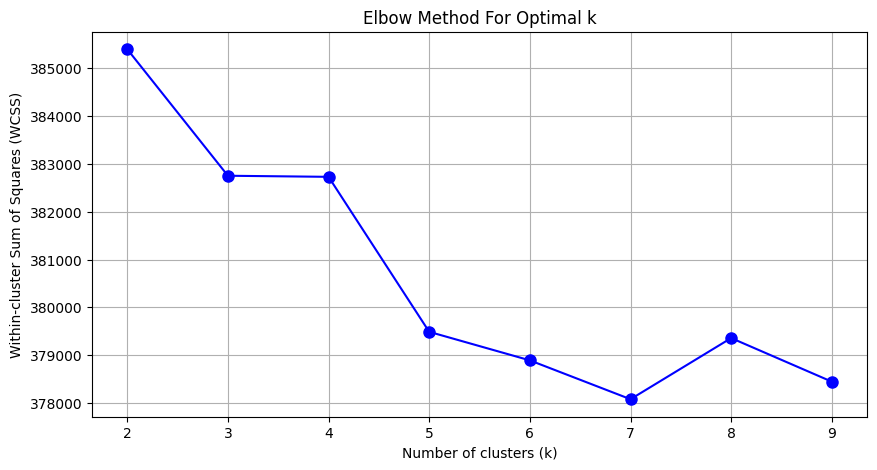

In [22]:
# Plot the elbow graph
plt.figure(figsize=(10, 5))
plt.plot(range_clusters, wcss, 'bo-', markersize=8)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within-cluster Sum of Squares (WCSS)')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()

# LDA

In [23]:
# Build the LDA model
# using the raw bag-of-words first
lda_model = LdaModel(bow_MP, num_topics = 4,
                     random_state = 2026,
                     id2word=dictionary_MP, passes=10)

In [24]:
# print the top words per topic
# interpret the top words to infer the topic label
lda_model.print_topics(num_words=10)

[(0,
  '0.027*"new" + 0.026*"zealand" + 0.013*"economic" + 0.012*"party" + 0.012*"south" + 0.010*"government" + 0.010*"policy" + 0.010*"act" + 0.008*"change" + 0.008*"growth"'),
 (1,
  '0.023*"new" + 0.015*"national" + 0.014*"government" + 0.012*"development" + 0.011*"infrastructure" + 0.009*"economy" + 0.009*"local" + 0.008*"investment" + 0.008*"water" + 0.008*"sector"'),
 (2,
  '0.034*"māori" + 0.018*"health" + 0.015*"education" + 0.014*"ensure" + 0.013*"support" + 0.010*"te" + 0.009*"access" + 0.009*"services" + 0.008*"schools" + 0.008*"people"'),
 (3,
  '0.013*"years" + 0.010*"social" + 0.010*"000" + 0.010*"year" + 0.009*"new" + 0.009*"rights" + 0.009*"people" + 0.008*"jobs" + 0.008*"tax" + 0.008*"increase"')]

In [25]:
# get the topic prevalence for one document
print(MP_toks[0])
lda_model.get_document_topics(bow_MP[0])

['democratic', 'national', 'convention', 'land', 'acknowledgement']


[(0, np.float32(0.8410044)),
 (1, np.float32(0.056757104)),
 (2, np.float32(0.051660284)),
 (3, np.float32(0.05057822))]

In [26]:
# save a document-topic distribution as dataframe
# Get the document-topic distribution
doc_topics = []
for i, doc in enumerate(bow_MP):
    doc_topics.append(lda_model.get_document_topics(doc, minimum_probability=0))

# Convert the document-topic distribution to a DataFrame
topic_dist_df = pd.DataFrame([[topic_prob[1] for topic_prob in doc] for doc in doc_topics])

In [27]:
topic_dist_df

,0,1,2,3
0,0.841024,0.056738,0.051660,0.050578
1,0.704762,0.021879,0.118877,0.154482
2,0.792203,0.029623,0.028509,0.149664
3,0.695428,0.022742,0.129066,0.152765
4,0.319201,0.113071,0.558403,0.009325
...,...,...,...,...
45550,0.598356,0.313790,0.042184,0.045670
45551,0.321856,0.209616,0.270628,0.197900
45552,0.063939,0.476256,0.062541,0.397265
45553,0.083533,0.728398,0.083362,0.104707


In [28]:
# identify the dominate topic for each document
doc_topics = []
for doc_bow in bow_MP:
    topic_probs = lda_model.get_document_topics(doc_bow)
    dominant_topic = max(topic_probs, key=lambda x: x[1])  # Get the topic with the highest probability
    doc_topics.append(dominant_topic)

In [29]:
doc_topics[0]

(0, np.float32(0.8409933))

In [30]:
# Convert to DataFrame
doc_dominant_topic = pd.DataFrame(doc_topics, columns=['DominantTopic', 'Probability'])
doc_dominant_topic.head()

,DominantTopic,Probability
0,0,0.840993
1,0,0.704765
2,0,0.792191
3,0,0.695426
4,2,0.558403


In [31]:
# given we identified dominant topic for each document
# we can easily find the most representative document for each topic
topic_documents = {}
num_documents = 10
for i in range(4):
  docs = doc_dominant_topic[doc_dominant_topic['DominantTopic'] == i]
  # sort the data frame in descending order
  docs.sort_values(by='Probability', ascending=False, inplace=True)
  topic_documents[f"topic_{i}"] = MP_toks[: num_documents]

/tmp/ipykernel_19230/3835472405.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  docs.sort_values(by='Probability', ascending=False, inplace=True)


In [32]:
# read the top documents for topic_0
topic_documents.get('topic_1')

[['democratic', 'national', 'convention', 'land', 'acknowledgement'],
 ['democratic',
  'national',
  'committee',
  'wishes',
  'acknowledge',
  'gather',
  'state',
  'values',
  'lands',
  'stewarded',
  'centuries',
  'ancestors',
  'descendants',
  'tribal',
  'nations',
  'time',
  'immemorial'],
 ['honor',
  'communities',
  'native',
  'continent',
  'recognize',
  'country',
  'built',
  'indigenous',
  'homelands'],
 ['pay',
  'respects',
  'millions',
  'indigenous',
  'people',
  'history',
  'protected',
  'lands',
  'waters',
  'animals'],
 ['respectfully',
  'acknowledge',
  'present',
  'platform',
  '2020',
  'democratic',
  'national',
  'convention',
  'lands',
  'bad',
  'river',
  'band',
  'lake',
  'superior',
  'tribe',
  'chippewa',
  'indians',
  'forest',
  'county',
  'potawatomi',
  'community',
  'ho',
  'chunk',
  'nation',
  'lac',
  'courte',
  'oreilles',
  'band',
  'lake',
  'superior',
  'chippewa',
  'lac',
  'du',
  'flambeau',
  'band',
  'lake',

# Visualizing LDA

In [33]:
!pip install pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 15.1 MB/s eta 0:00:00


In [34]:
import warnings
warnings.filterwarnings(action="ignore", message=r"datetime.datetime.utcnow()")
# for more information of pyLDAvis
# https://github.com/bmabey/pyLDAvis
import pyLDAvis.gensim_models
import pyLDAvis

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [35]:
pyLDAvis.enable_notebook()  # For Jupyter/Colab display
vis = pyLDAvis.gensim_models.prepare(lda_model, bow_MP, dictionary_MP)
vis

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.090938 -0.286849       1        1  26.497520
3      0.344585  0.032280       2        1  24.605796
2     -0.149443  0.236108       3        1  24.513642
1     -0.104204  0.018461       4        1  24.383041, topic_info=           Term         Freq        Total Category  logprob  loglift
4569      māori  3098.000000  3098.000000  Default  30.0000  30.0000
3632    zealand  2497.000000  2497.000000  Default  29.0000  29.0000
82       health  1614.000000  1614.000000  Default  28.0000  28.0000
125   education  1385.000000  1385.000000  Default  27.0000  27.0000
186         new  5570.000000  5570.000000  Default  26.0000  26.0000
...         ...          ...          ...      ...      ...      ...
471     support   443.312126  2290.057531   Topic4  -5.3118  -0.2308
2          land   390.826774   969.253197   Topic4  -5.4378   0.5030
126      future   362.264476   683.955208   Topic4  -5.5137   0.7758
775        fund   363.180993   708.966015   Topic4  -5.5112   0.7424
597        work   378.122162  1559.207811   Topic4  -5.4708  -0.0054

[218 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
639       2  0.999324      000
1812      2  0.998107        1
897       2  0.998918       10
92        2  0.102907       19
92        4  0.896226       19
...     ...       ...      ...
70        4  0.373489    world
1070      2  0.999044     year
169       2  0.999760    years
1384      2  0.998245    youth
3632      1  0.999538  zealand

[259 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 4, 3, 2])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag